# 郑州市气温数据分析与预测

## 1.导入模块

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
import csv
import seaborn as sns
from lxml import etree
from datetime import datetime
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 2.数据收集

### 2.1数据爬取

In [24]:
def get_weather(url):
    weather_info = []  # 新建一个列表，将爬取的每月数据放进去
    # 请求头信息
    headers = {
         'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'    
    }
    # 请求
    resp = requests.get(url, headers=headers)
    # 数据预处理
    resp_html = etree.HTML(resp.text)
    # xpath提取所有数据
    resp_list = resp_html.xpath("//ul[@class='thrui']/li")
    #for循环迭代遍历
    for li in resp_list:
        # 定义每天的天气数据字典
        day_weather_info = {
            # 获取日期，格式为 2024-01-01
            'date_time': li.xpath("./div[1]/text()")[0].split(' ')[0],
            # 获取最高气温，并去除摄氏度符号
            'high': li.xpath("./div[2]/text()")[0].replace('C',''),
            # 获取最低气温，并去除摄氏度符号
            'low': li.xpath("./div[3]/text()")[0].replace('C',''),
            # 获取天气文本信息
            'weather': li.xpath("./div[4]/text()")[0],
            #获取风向文本信息
            'wind': li.xpath("./div[5]/text()")[0]
        }
        # 再将每天的数据字典放入每月数据列表中
        weather_info.append(day_weather_info)
    # 返回每个月天气数据表
    return weather_info

weathers = []

# for循环生成有顺序的1-12
for month in range(1,13):
    # 获取对应月份的天气信息
    weather_time = f'2024{month:02}'
    url = f'https://lishi.tianqi.com/zhengzhou/{weather_time}.html'
    weather = get_weather(url)
    # 存到列表中
    weathers.append(weather)

print(weathers)

# 数据写入
with open("weather.csv","w",newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["日期","最高气温","最低气温","天气","风向"])
    # 遍历出每个月的天气信息
    for month_weather in weathers:
        for day_weather_dict in month_weather:
            writer.writerow(list(day_weather_dict.values()))

[[{'date_time': '2024-01-01', 'high': '9℃', 'low': '-2℃', 'weather': '多云', 'wind': '西南风 1级'}, {'date_time': '2024-01-02', 'high': '12℃', 'low': '0℃', 'weather': '晴', 'wind': '西北风 3级'}, {'date_time': '2024-01-03', 'high': '12℃', 'low': '-1℃', 'weather': '晴', 'wind': '西风 2级'}, {'date_time': '2024-01-04', 'high': '14℃', 'low': '-1℃', 'weather': '晴', 'wind': '西风 3级'}, {'date_time': '2024-01-05', 'high': '11℃', 'low': '-2℃', 'weather': '多云', 'wind': '西北风 1级'}, {'date_time': '2024-01-06', 'high': '10℃', 'low': '-4℃', 'weather': '多云~晴', 'wind': '东北风 3级'}, {'date_time': '2024-01-07', 'high': '6℃', 'low': '-3℃', 'weather': '晴', 'wind': '东南风 2级'}, {'date_time': '2024-01-08', 'high': '9℃', 'low': '0℃', 'weather': '晴~多云', 'wind': '西南风 2级'}, {'date_time': '2024-01-09', 'high': '9℃', 'low': '-3℃', 'weather': '多云~晴', 'wind': '北风 3级'}, {'date_time': '2024-01-10', 'high': '9℃', 'low': '-2℃', 'weather': '多云~晴', 'wind': '西南风 2级'}], [{'date_time': '2024-02-01', 'high': '-2℃', 'low': '-4℃', 'weather': '阴',

### 2.2查看数据

In [4]:
# 读取数据
df = pd.read_csv('weather.csv', encoding='gbk')
# 查看数据前五行
df.head()

,日期,最高气温,最低气温,天气,风向
0,2024-01-01,9℃,-2℃,多云,西南风 1级
1,2024-01-02,12℃,0℃,晴,西北风 3级
2,2024-01-03,12℃,-1℃,晴,西风 2级
3,2024-01-04,14℃,-1℃,晴,西风 3级
4,2024-01-05,11℃,-2℃,多云,西北风 1级


## 3.数据预处理

### 3.1数据异常检查处理

In [5]:
# 数据描述统计
stats = df.describe()
stats

,日期,最高气温,最低气温,天气,风向
count,120,120,120,120,120
unique,120,37,34,27,26
top,2024-01-01,30℃,23℃,阴~多云,东南风 2级
freq,1,9,9,19,24


In [6]:
# 检查并处理缺失值
print("缺失值数量:", df.isnull().sum())
df.dropna(inplace=True)

缺失值数量: 日期      0
最高气温    0
最低气温    0
天气      0
风向      0
dtype: int64


In [7]:
#查看列的数据类型以及这些列中有多少非空值
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   日期      120 non-null    object
 1   最高气温    120 non-null    object
 2   最低气温    120 non-null    object
 3   天气      120 non-null    object
 4   风向      120 non-null    object
dtypes: object(5)
memory usage: 4.8+ KB


In [8]:
#查看重复值情况
df.duplicated().sum()

0

### 3.2数据清洗

In [9]:
# 去除气温中的'℃'符号并转为数值
df['最高气温'] = df['最高气温'].str.replace('℃', '').astype(float)
df['最低气温'] = df['最低气温'].str.replace('℃', '').astype(float)
 
# 提取主要天气（取第一个天气状态）
df['主要天气'] = df['天气'].str.split('~').str[0]
 
# 提取风力等级（如“西南风 1级” -> 1）
df['风力等级'] = df['风向'].str.extract(r'(\d+)级').astype(int)
 
# 转换日期列
df['日期'] = pd.to_datetime(df['日期'])
 
# 排序确保时间顺序
df = df.sort_values('日期').reset_index(drop=True)
 
# 创建时间索引变量（用于线性回归）
df['天数'] = (df['日期'] - df['日期'].min()).dt.days
 
# 仅保留关键字段用于建模
data = df[['日期', '最高气温', '最低气温', '天数']].copy()

## 4.数据可视化

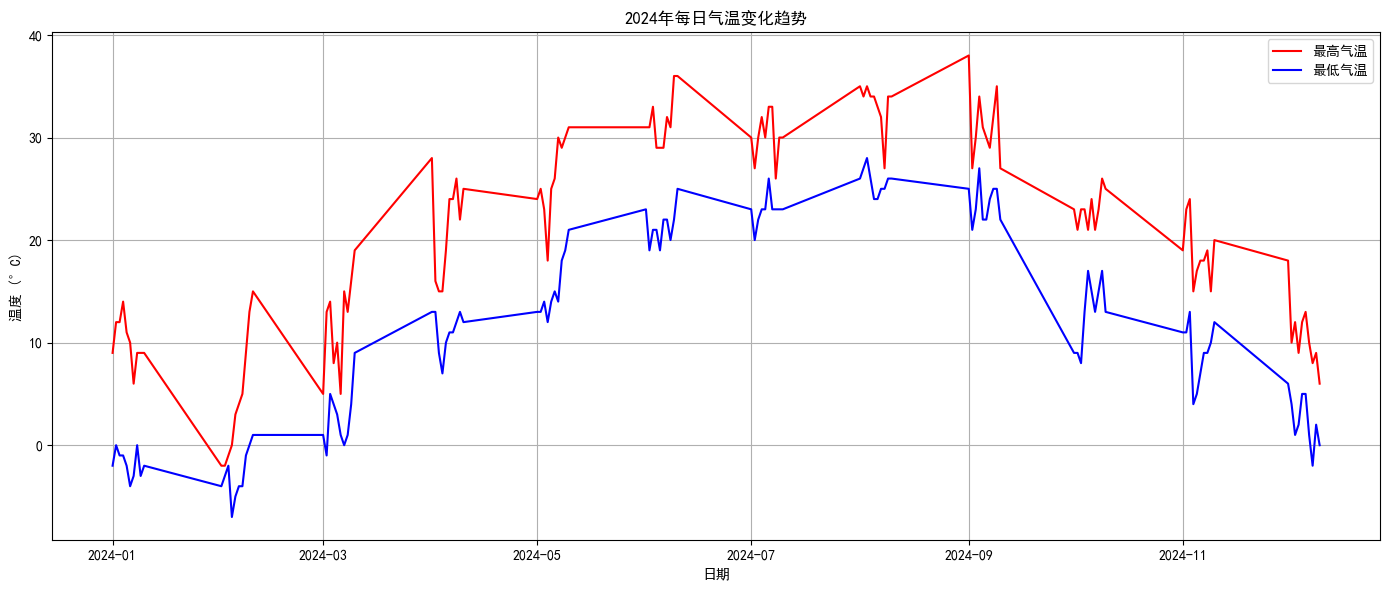

In [10]:
# 整体气温变化趋势图
plt.figure(figsize=(14, 6))
plt.plot(data['日期'], data['最高气温'], label='最高气温', color='red')
plt.plot(data['日期'], data['最低气温'], label='最低气温', color='blue')
plt.title('2024年每日气温变化趋势')
plt.xlabel('日期')
plt.ylabel('温度 (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
save_path = 'C:\\Users\\李晓冉\\基于时间序列的气温分析与预测\\figures\\trend_plot.png'
plt.savefig(save_path,dpi=600,bbox_inches='tight')
plt.show()

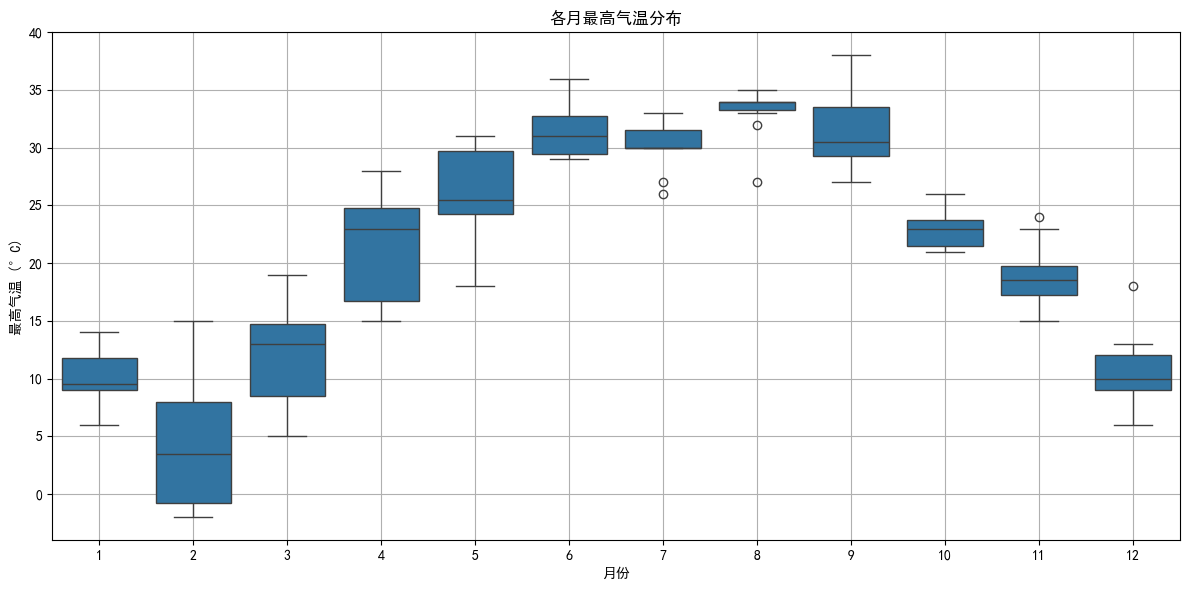

In [11]:
# 月均气温箱线图
df['月份'] = df['日期'].dt.month
plt.figure(figsize=(12, 6))
sns.boxplot(x='月份', y='最高气温', data=df)
plt.title('各月最高气温分布')
plt.xlabel('月份')
plt.ylabel('最高气温 (°C)')
plt.grid(True)
plt.tight_layout()
save_path = 'C:\\Users\\李晓冉\\基于时间序列的气温分析与预测\\figures\\boxplot_monthly.png'
plt.savefig(save_path,dpi=600,bbox_inches='tight')
plt.show()

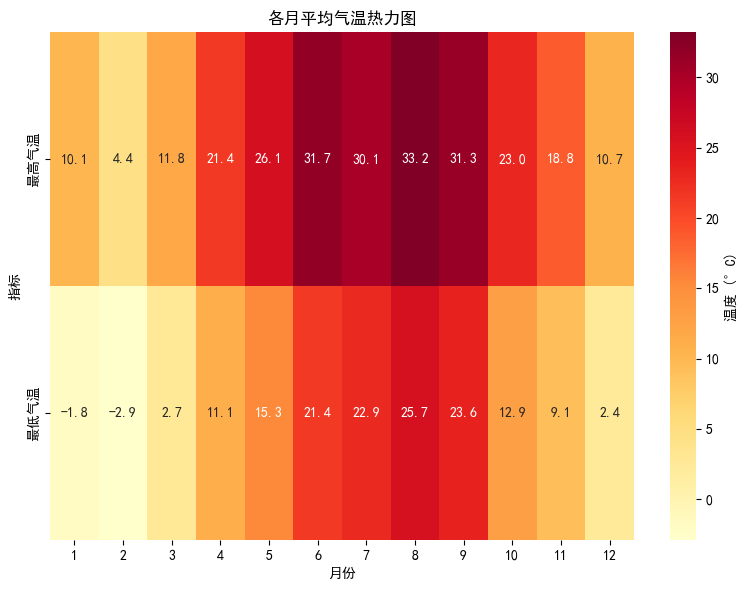

In [12]:
# 月均气温交叉表
# 提取月份 
df['月份'] = df['日期'].dt.month
monthly_avg = df.groupby('月份')[['最高气温', '最低气温']].mean()
 
# 创建热力图 
plt.figure(figsize=(8, 6))
sns.heatmap(monthly_avg.T, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': '温度 (°C)'})
plt.title('各月平均气温热力图')
plt.ylabel('指标')
plt.xlabel('月份')
plt.tight_layout()
save_path = 'C:\\Users\\李晓冉\\基于时间序列的气温分析与预测\\figures\\heatmap_avgtemp.png'
plt.savefig(save_path,dpi=600,bbox_inches='tight')
plt.show()

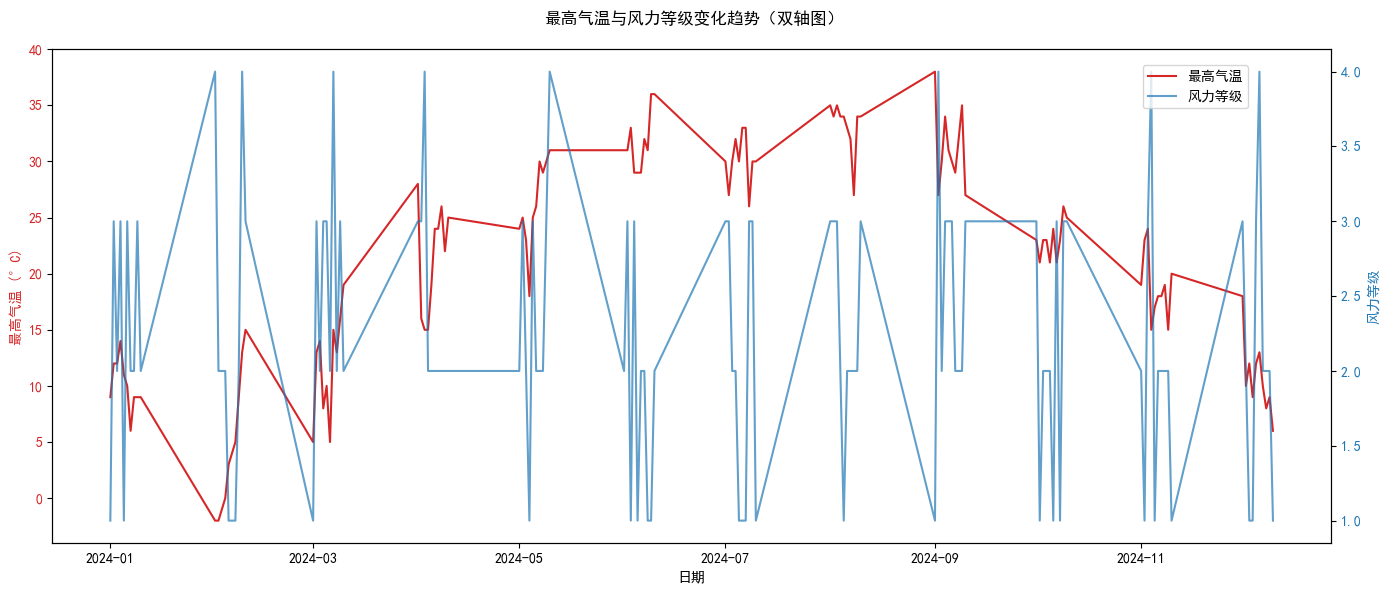

In [13]:
# 气温和风力等级趋势叠加双轴折线图
fig, ax1 = plt.subplots(figsize=(14, 6))
 
# 主Y轴：最高气温 
color = 'tab:red'
ax1.set_xlabel('日期')
ax1.set_ylabel('最高气温 (°C)', color=color)
ax1.plot(df['日期'], df['最高气温'], color=color, label='最高气温')
ax1.tick_params(axis='y', labelcolor=color)
 
# 次Y轴：风力等级
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('风力等级', color=color)
ax2.plot(df['日期'], df['风力等级'], color=color, alpha=0.7, label='风力等级')
ax2.tick_params(axis='y', labelcolor=color)
 
# 标题与图例
fig.suptitle('最高气温与风力等级变化趋势（双轴图）')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
save_path = 'C:\\Users\\李晓冉\\基于时间序列的气温分析与预测\\figures\\temp_wind_trend.png'
plt.savefig(save_path,dpi=600,bbox_inches='tight')
plt.show()

## 5.数据的建模分析

### 5.1线性回归模型

In [14]:
#简单线性回归

X = data[['天数']]
y_high = data['最高气温']
 
lr_model = LinearRegression()
lr_model.fit(X, y_high)
 
# 预测整个训练集
y_pred_lr = lr_model.predict(X)
 
# 输出R²得分
print(f"线性回归 R² 得分: {r2_score(y_high, y_pred_lr):.4f}")

线性回归 R² 得分: 0.1163


In [15]:
# 添加周期性特征：正弦/余弦变换（周期365天）
data['sin_day'] = np.sin(2 * np.pi * data['天数'] / 365)
data['cos_day'] = np.cos(2 * np.pi * data['天数'] / 365)
 
X_cycle = data[['天数', 'sin_day', 'cos_day']]
lr_cycle = LinearRegression()
lr_cycle.fit(X_cycle, y_high)
y_pred_cycle = lr_cycle.predict(X_cycle)
 
print(f"带周期项的线性回归 R²: {r2_score(y_high, y_pred_cycle):.4f}")

带周期项的线性回归 R²: 0.8502


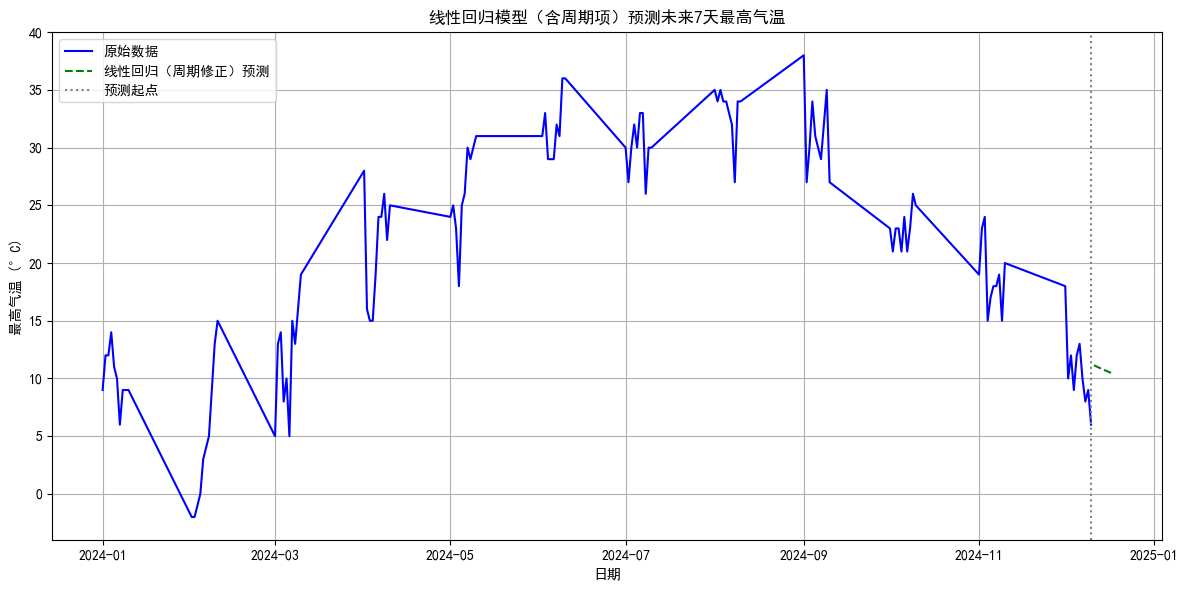

In [16]:
# 预测未来七天

forecast_steps = 7
future_days = np.arange(data['天数'].max() + 1, data['天数'].max() + 8)
future_sin = np.sin(2 * np.pi * future_days / 365)
future_cos = np.cos(2 * np.pi * future_days / 365)

# 构造预测日期 
last_date = data['日期'].iloc[-1]
forecast_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=forecast_steps)

X_future = np.column_stack([future_days, future_sin, future_cos])
forecast_lr = lr_cycle.predict(X_future)
 
# 可视化对比 
plt.figure(figsize=(12, 6))
plt.plot(data['日期'], data['最高气温'], label='原始数据', color='blue')
plt.plot(forecast_dates, forecast_lr, label='线性回归（周期修正）预测', color='green', linestyle='--')
plt.axvline(last_date, color='gray', linestyle=':', label='预测起点')
plt.title('线性回归模型（含周期项）预测未来7天最高气温')
plt.xlabel('日期')
plt.ylabel('最高气温 (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
save_path = 'C:\\Users\\李晓冉\\基于时间序列的气温分析与预测\\figures\\prediction_compare.png'
plt.savefig(save_path,dpi=600,bbox_inches='tight')
plt.show()

### 5.2ARIMA 时间序列模型（针对最高气温）

In [17]:
# 检查平稳性（ADF检验）
def check_stationarity(ts, title):
    result = adfuller(ts.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("序列平稳")
    else:
        print("序列非平稳")
 
check_stationarity(data['最高气温'], '原始最高气温')

ADF Statistic: -0.919560667899572
p-value: 0.7814625797967694
序列非平稳


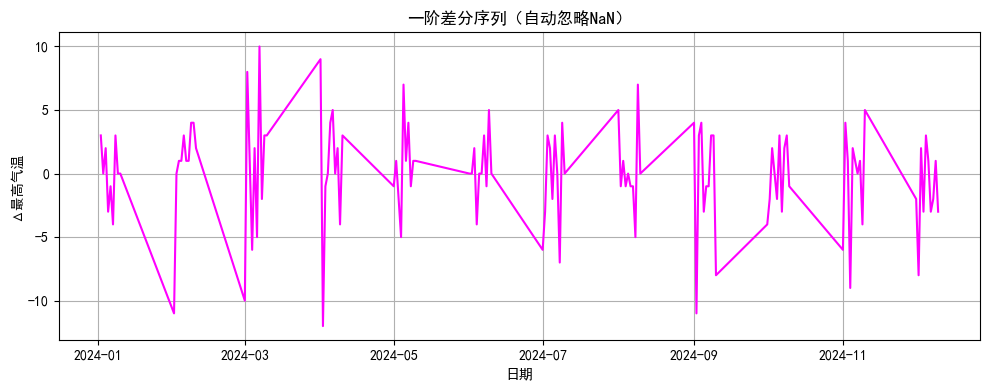

ADF Statistic: -8.703838418432719
p-value: 3.7463709020975395e-14
序列平稳


In [18]:
# 差分处理
data['diff_high'] = data['最高气温'].diff().dropna()
 
# 安全绘制一阶差分图
plt.figure(figsize=(10, 4))
diff_vals = data['最高气温'].diff()
plt.plot(data['日期'], diff_vals, color='magenta')
plt.title('一阶差分序列（自动忽略NaN）')
plt.ylabel('Δ最高气温')
plt.xlabel('日期')
plt.grid(True)
plt.tight_layout()
plt.show()

# 再次检验平稳性
check_stationarity(data['diff_high'], '一阶差分后')

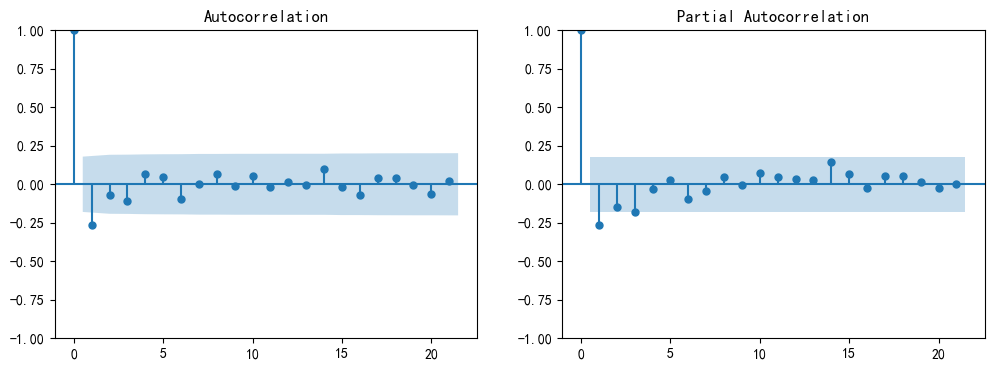

In [19]:
# 确定ARIMA参数（p, d, q）
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(data['diff_high'].dropna(), ax=ax[0])
plot_pacf(data['diff_high'].dropna(), ax=ax[1])
plt.show()

In [20]:
# 拟合ARIMA模型
model_arima = ARIMA(data['最高气温'], order=(2, 1, 2))
result_arima = model_arima.fit()
 
print(result_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                   最高气温   No. Observations:                  120
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -325.516
Date:                Wed, 31 Dec 2025   AIC                            661.031
Time:                        09:47:54   BIC                            674.927
Sample:                             0   HQIC                           666.674
                                - 120                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6720      0.332     -2.024      0.043      -1.323      -0.021
ar.L2          0.2913      0.265      1.101      0.271      -0.227       0.810
ma.L1          0.3278      0.295      1.111      0.2

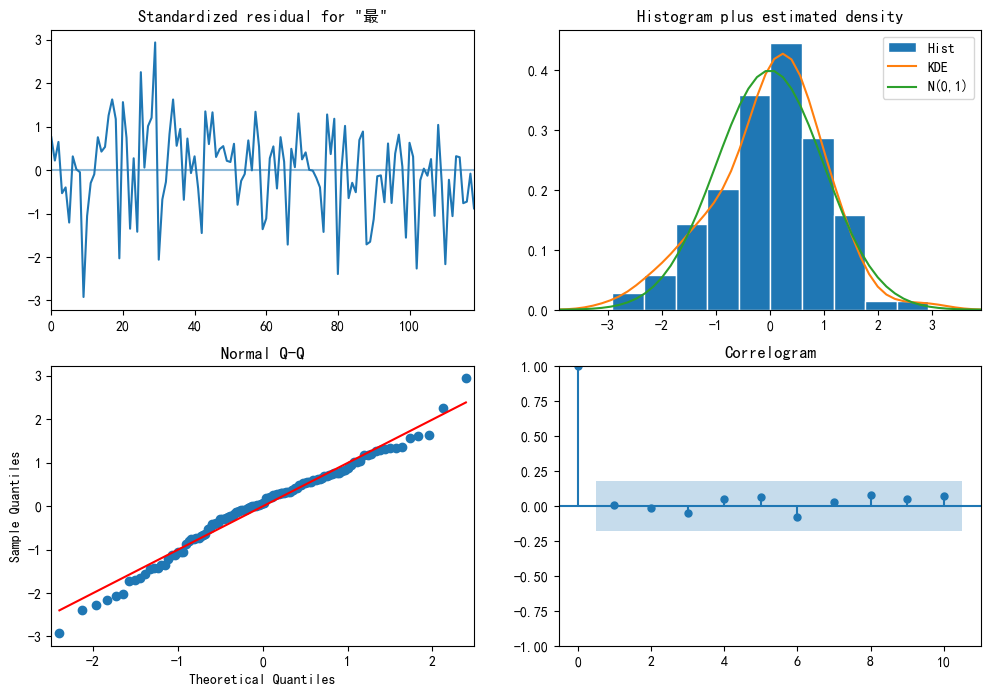

In [21]:
# 模型诊断
result_arima.plot_diagnostics(figsize=(12, 8))
plt.show()

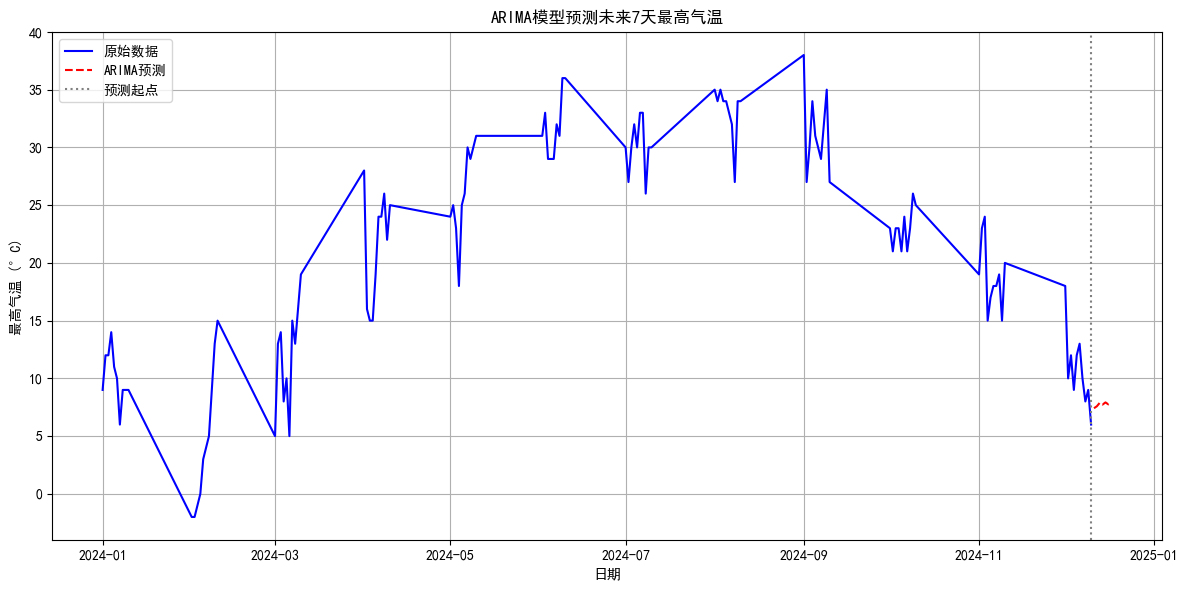

In [22]:
# 预测未来七天
forecast_steps = 7
forecast_arima = result_arima.forecast(steps=forecast_steps)
 
# 构造预测日期 
last_date = data['日期'].iloc[-1]
forecast_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=forecast_steps)
 
# 可视化预测结果
plt.figure(figsize=(12, 6))
plt.plot(data['日期'], data['最高气温'], label='原始数据', color='blue')
plt.plot(forecast_dates, forecast_arima, label='ARIMA预测', color='red', linestyle='--')
plt.axvline(last_date, color='gray', linestyle=':', label='预测起点')
plt.title('ARIMA模型预测未来7天最高气温')
plt.xlabel('日期')
plt.ylabel('最高气温 (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()